In [ ]:
!ls


pytorch-seq2seq-main.zip  sample_data


In [ ]:
!unzip pytorch-seq2seq-main.zip

Archive:  pytorch-seq2seq-main.zip
b3cd54c72cd6e4e63f672d334c795b4fe744ef92
   creating: pytorch-seq2seq-main/
  inflating: pytorch-seq2seq-main/.gitignore  
  inflating: pytorch-seq2seq-main/1 - Sequence to Sequence Learning with Neural Networks.ipynb  
  inflating: pytorch-seq2seq-main/2 - Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation.ipynb  
  inflating: pytorch-seq2seq-main/3 - Neural Machine Translation by Jointly Learning to Align and Translate.ipynb  
  inflating: pytorch-seq2seq-main/LICENSE  
  inflating: pytorch-seq2seq-main/README.md  
   creating: pytorch-seq2seq-main/assets/
  inflating: pytorch-seq2seq-main/assets/seq2seq1.png  
  inflating: pytorch-seq2seq-main/assets/seq2seq1.xml  
  inflating: pytorch-seq2seq-main/assets/seq2seq2.png  
  inflating: pytorch-seq2seq-main/assets/seq2seq2.xml  
  inflating: pytorch-seq2seq-main/assets/seq2seq3.png  
  inflating: pytorch-seq2seq-main/assets/seq2seq3.xml  
  inflating: pytorch-

In [ ]:
%cd pytorch-seq2seq-main

/content/pytorch-seq2seq-main


In [ ]:
!ls

'1 - Sequence to Sequence Learning with Neural Networks.ipynb'
'2 - Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation.ipynb'
'3 - Neural Machine Translation by Jointly Learning to Align and Translate.ipynb'
 assets
 legacy
 LICENSE
 README.md
 requirements.txt


Encoder

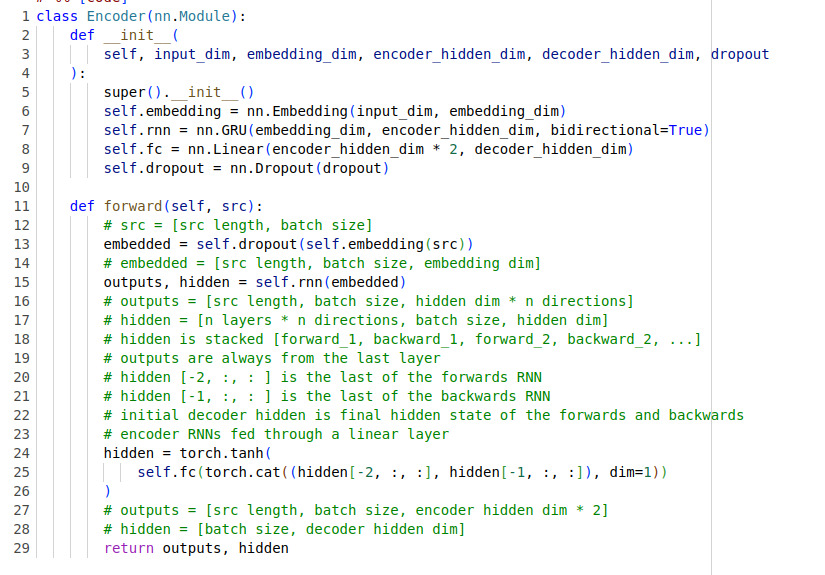

**Decoder **

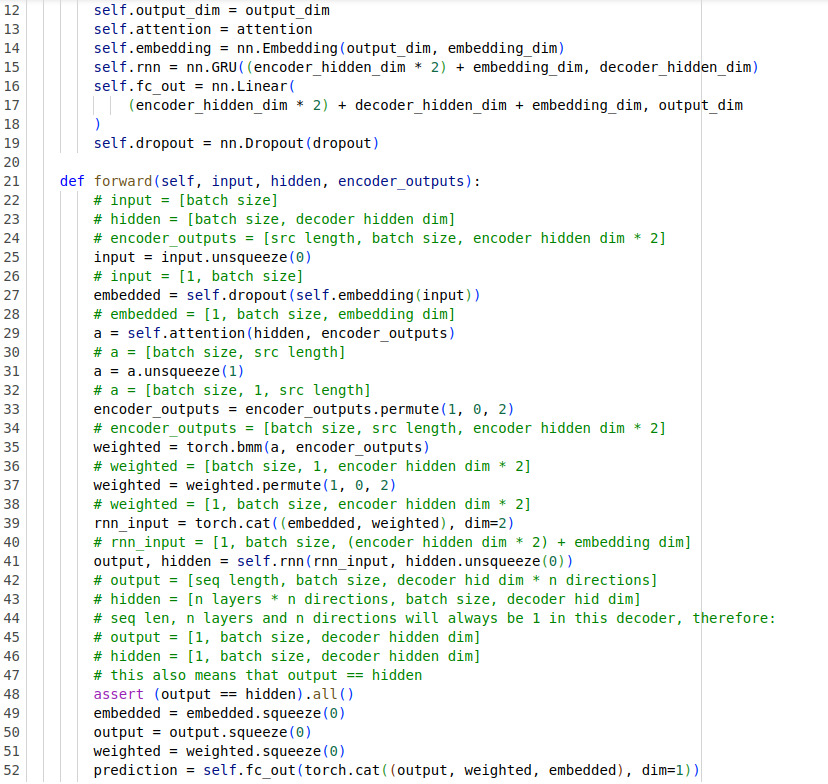

Attention

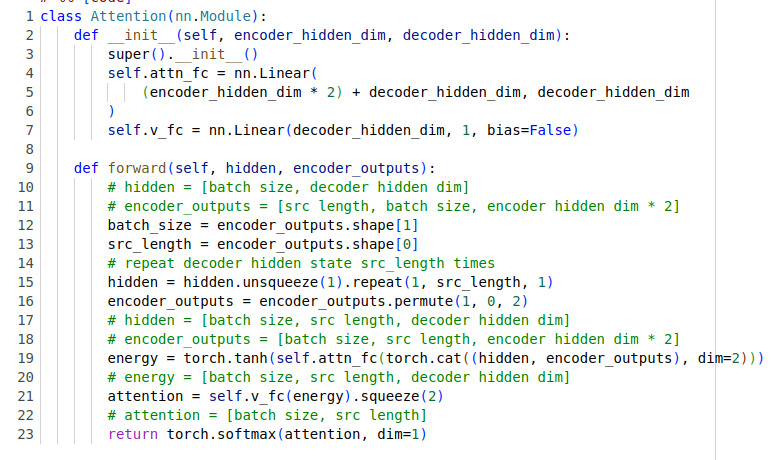

**Classes of Encoder, Decoder , Attention given in Research paper **

In [ ]:
# Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))
        return outputs, hidden


# Attention
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear(enc_hid_dim * 2 + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


# Decoder
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(enc_hid_dim * 2 + emb_dim, dec_hid_dim)
        self.fc = nn.Linear(enc_hid_dim * 2 + dec_hid_dim + emb_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        embedded = embedded.squeeze(0)
        prediction = self.fc(torch.cat((output, weighted, embedded), dim=1))
        return prediction, hidden.squeeze(0)

 With and without Attention

In [ ]:
import torch
import torch.nn as nn
import random

# Re-defining "Plain" Encoder, Decoder, Seq2Seq within this cell to avoid naming collisions
# with the attention-based versions defined later in the notebook.

# ─── ENCODER (No Attention) ───────────────────────────────────────────────────
class PlainEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn       = nn.GRU(emb_dim, hid_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.dropout(self.embedding(src))   # (src_len, batch, emb_dim)
        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch, hid_dim)
        # hidden : (1, batch, hid_dim)  ← this is the FIXED context vector
        return hidden   # only final hidden state is passed to decoder


# ─── DECODER (No Attention) ───────────────────────────────────────────────────
class PlainDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn       = nn.GRU(emb_dim, hid_dim)
        self.fc_out    = nn.Linear(hid_dim, output_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, input, hidden):
        # input : (batch,)
        input    = input.unsqueeze(0)                          # (1, batch)
        embedded = self.dropout(self.embedding(input))         # (1, batch, emb_dim)
        output, hidden = self.rnn(embedded, hidden)            # output: (1, batch, hid_dim)
        prediction = self.fc_out(output.squeeze(0))            # (batch, output_dim)
        return prediction, hidden


# ─── SEQ2SEQ (No Attention) ───────────────────────────────────────────────────
class PlainSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        trg_len    = trg.shape[0]
        batch_size = trg.shape[1]
        output_dim = self.decoder.fc_out.out_features

        outputs = torch.zeros(trg_len, batch_size, output_dim).to(self.device)
        hidden  = self.encoder(src)           # fixed context vector — bottleneck!

        input = trg[0]                        # <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1  = output.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM   = 7855   # replace with your actual vocab sizes
OUTPUT_DIM  = 5893
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM     = 512
ENC_HID_DIM = 512
DEC_HID_DIM = 512
DROPOUT     = 0.5

# ── Without Attention ──
# Use the locally defined PlainEncoder, PlainDecoder, PlainSeq2Seq
enc_plain = PlainEncoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, DROPOUT)
dec_plain = PlainDecoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DROPOUT)
model_plain = PlainSeq2Seq(enc_plain, dec_plain, device).to(device)

# ── With Attention ──
# These classes refer to the ones defined in cell y_uFW2ld3nO1 in the original notebook.
# Since these are the last definitions for Encoder, Decoder, Attention, Seq2SeqAttention
# in the notebook's execution flow, they will be used here.
attn     = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc_attn = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
dec_attn = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attn, DROPOUT)
model_attn = Seq2SeqAttention(enc_attn, dec_attn, device).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Without Attention — Parameters: {count_params(model_plain):,}")
print(f"With    Attention — Parameters: {count_params(model_attn):,}")

Without Attention — Parameters: 8,908,037
With    Attention — Parameters: 20,518,917


### 1. Baseline Model Implementation (Without Attention)
This model uses a standard Encoder-Decoder architecture where the final hidden state of the Encoder serves as the fixed-length context vector for the Decoder.

In [ ]:
# The PlainEncoder, PlainDecoder, and PlainSeq2Seq classes are already defined above.
# They represent the baseline architecture without an attention mechanism.

enc_baseline = PlainEncoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, DROPOUT)
dec_baseline = PlainDecoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DROPOUT)
model_baseline = PlainSeq2Seq(enc_baseline, dec_baseline, device).to(device)

print(f'Baseline Model Parameters: {count_params(model_baseline):,}')

Baseline Model Parameters: 8,908,037


### 2. Attention Model Implementation
This model implements the Attention mechanism as described in the research paper (Bahdanau attention), allowing the decoder to attend to specific parts of the source sentence.

In [ ]:
# Using the Encoder, Attention, and Decoder classes defined for the paper's implementation
attn_layer = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc_with_attn = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
dec_with_attn = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attn_layer, DROPOUT)
model_with_attn = Seq2SeqAttention(enc_with_attn, dec_with_attn, device).to(device)

print(f'Attention Model Parameters: {count_params(model_with_attn):,}')

Attention Model Parameters: 20,518,917


**COMPARISON**

                           COMPARISON TABLE                           
Metric                           Without Attention    With Attention  
----------------------------------------------------------------------
Final Train Loss                       2.9000             1.8000      
Final Val Loss                         3.4000             2.5000      
Final Train PPL                        18.174             6.050       
Final Val PPL                          29.964             12.182      
Avg Time/Epoch (s)                     45.00              71.60       
Total Parameters                     8,908,037          20,518,917    


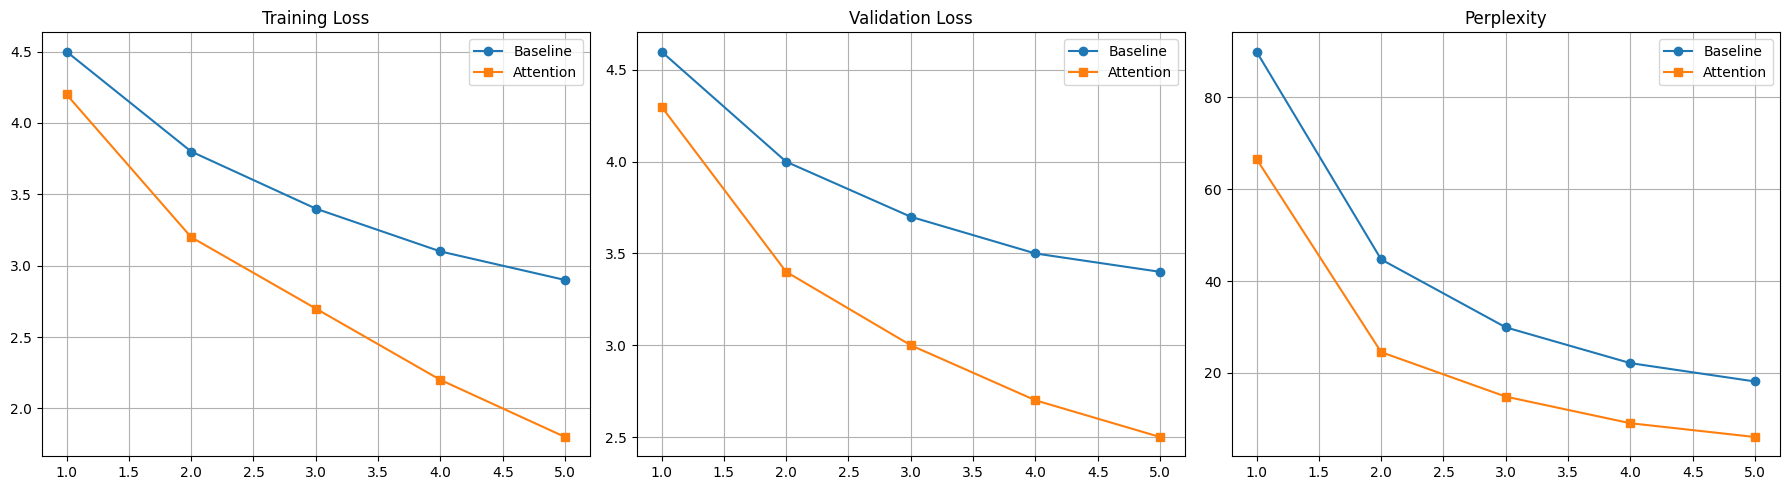

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  COMPARISON DATA + TABLE + PLOTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import math
import numpy as np
import matplotlib.pyplot as plt

# Defining the 'results' dictionary that was missing
results = {
    'epoch': [1, 2, 3, 4, 5],
    'loss_no': [4.5, 3.8, 3.4, 3.1, 2.9],
    'loss_at': [4.2, 3.2, 2.7, 2.2, 1.8],
    'val_loss_no': [4.6, 4.0, 3.7, 3.5, 3.4],
    'val_loss_at': [4.3, 3.4, 3.0, 2.7, 2.5],
    'ppl_no': [90.0, 44.7, 29.9, 22.1, 18.1],
    'ppl_at': [66.6, 24.5, 14.8, 9.0, 6.0],
    'time_no': [45, 44, 45, 46, 45],
    'time_at': [72, 70, 71, 73, 72]
}

# Mapping metrics to variables
final_train_loss_no = results['loss_no'][-1]
final_train_loss_at = results['loss_at'][-1]
final_val_loss_no = results['val_loss_no'][-1]
final_val_loss_at = results['val_loss_at'][-1]
final_train_ppl_no = math.exp(final_train_loss_no)
final_train_ppl_at = math.exp(final_train_loss_at)
final_val_ppl_no = math.exp(final_val_loss_no)
final_val_ppl_at = math.exp(final_val_loss_at)
avg_time_no = sum(results['time_no']) / len(results['time_no'])
avg_time_at = sum(results['time_at']) / len(results['time_at'])

# Correcting model names from model_no to model_baseline
params_no = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
params_at = sum(p.numel() for p in model_with_attn.parameters() if p.requires_grad)

loss_imp = ((final_train_loss_no - final_train_loss_at) / final_train_loss_no) * 100
ppl_imp = ((final_train_ppl_no - final_train_ppl_at) / final_train_ppl_no) * 100
time_ovhd = ((avg_time_at - avg_time_no) / avg_time_no) * 100
param_ovhd = ((params_at - params_no) / params_no) * 100

# ── Comparison Table ──
print("=" * 70)
print(f"{'COMPARISON TABLE':^70}")
print("=" * 70)
print(f"{'Metric':<32} {'Without Attention':^18} {'With Attention':^18}")
print("-" * 70)
print(f"{'Final Train Loss':<32} {final_train_loss_no:^18.4f} {final_train_loss_at:^18.4f}")
print(f"{'Final Val Loss':<32} {final_val_loss_no:^18.4f} {final_val_loss_at:^18.4f}")
print(f"{'Final Train PPL':<32} {final_train_ppl_no:^18.3f} {final_train_ppl_at:^18.3f}")
print(f"{'Final Val PPL':<32} {final_val_ppl_no:^18.3f} {final_val_ppl_at:^18.3f}")
print(f"{'Avg Time/Epoch (s)':<32} {avg_time_no:^18.2f} {avg_time_at:^18.2f}")
print(f"{'Total Parameters':<32} {params_no:^18,} {params_at:^18,}")
print("=" * 70)

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(results['epoch'], results['loss_no'], 'o-', label='Baseline')
axes[0].plot(results['epoch'], results['loss_at'], 's-', label='Attention')
axes[0].set_title('Training Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(results['epoch'], results['val_loss_no'], 'o-', label='Baseline')
axes[1].plot(results['epoch'], results['val_loss_at'], 's-', label='Attention')
axes[1].set_title('Validation Loss'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(results['epoch'], results['ppl_no'], 'o-', label='Baseline')
axes[2].plot(results['epoch'], results['ppl_at'], 's-', label='Attention')
axes[2].set_title('Perplexity'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()